In [40]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import (
    round_metrics_with_ci_table,
    summarize_metrics_with_ci,
    summarize_metrics_with_ci_from_values,
)

In [41]:
fp32_path = "../../../full_precision/memorization/experiments"

# Attack mem ep

In [42]:
expath = '../attack_mem_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_ep/attack_mem_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '15b_ep0', '15b_ep0_em', '15b_ep0_bleu', '15b_ep0_meteor',
       '15b_ep0_rougeL', '15b_ep1', '15b_ep1_em', '15b_ep1_bleu',
       '15b_ep1_meteor', '15b_ep1_rougeL', '15b_ep2', '15b_ep2_em',
       '15b_ep2_bleu', '15b_ep2_meteor', '15b_ep2_rougeL', '15b_ep3',
       '15b_ep3_em', '15b_ep3_bleu', '15b_ep3_meteor', '15b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [43]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_fp32_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'15b_{ep}_{metric}',
)
ep_fp32_absolute = ep_fp32_absolute_ci[metrics].copy()
ep_fp32_absolute_ci = round_metrics_with_ci_table(ep_fp32_absolute_ci, decimals=3)
ep_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.300,"[0.272, 0.329]",57.591,"[55.063, 60.083]",0.631,"[0.607, 0.654]",0.625,"[0.601, 0.649]"
ep1,0.549,"[0.518, 0.58]",75.689,"[73.311, 78.052]",0.780,"[0.758, 0.802]",0.783,"[0.761, 0.804]"
ep2,0.567,"[0.536, 0.597]",76.090,"[73.766, 78.417]",0.784,"[0.762, 0.806]",0.784,"[0.761, 0.806]"
ep3,0.609,"[0.578, 0.639]",77.444,"[75.171, 79.75]",0.801,"[0.78, 0.822]",0.797,"[0.775, 0.818]"


In [44]:
# With the baseline
first = ep_fp32_absolute.iloc[0]

ep_fp32_baseline = ep_fp32_absolute.subtract(first)
ep_fp32_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.249,18.098435,0.149609,0.157920
ep2,0.267,18.499219,0.153450,0.158654
ep3,0.309,19.853200,0.170851,0.171755


### bf16

In [45]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_bf16_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'bf16_{ep}_{metric}',
)
ep_bf16_absolute = ep_bf16_absolute_ci[metrics].copy()
ep_bf16_absolute_ci = round_metrics_with_ci_table(ep_bf16_absolute_ci, decimals=3)
ep_bf16_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.302,"[0.274, 0.331]",57.615,"[55.1, 60.113]",0.629,"[0.606, 0.652]",0.624,"[0.6, 0.648]"
ep1,0.550,"[0.519, 0.581]",75.717,"[73.351, 78.081]",0.780,"[0.758, 0.802]",0.783,"[0.76, 0.804]"
ep2,0.571,"[0.54, 0.601]",76.070,"[73.751, 78.408]",0.784,"[0.761, 0.806]",0.783,"[0.76, 0.805]"
ep3,0.610,"[0.579, 0.64]",77.305,"[75.016, 79.62]",0.801,"[0.779, 0.822]",0.796,"[0.773, 0.817]"


In [46]:
# With the baseline
first = ep_bf16_absolute.iloc[0]

ep_bf16_baseline = ep_bf16_absolute.subtract(first)
ep_bf16_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.248,18.102107,0.151093,0.158341
ep2,0.269,18.455052,0.155162,0.158378
ep3,0.308,19.690140,0.171695,0.171181


## int8

In [47]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_i8_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'i8_{ep}_{metric}',
)
ep_i8_absolute = ep_i8_absolute_ci[metrics].copy()
ep_i8_absolute_ci = round_metrics_with_ci_table(ep_i8_absolute_ci, decimals=3)
ep_i8_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.297,"[0.269, 0.326]",57.121,"[54.607, 59.623]",0.628,"[0.605, 0.652]",0.620,"[0.596, 0.644]"
ep1,0.540,"[0.509, 0.571]",75.559,"[73.216, 77.915]",0.780,"[0.758, 0.802]",0.782,"[0.76, 0.803]"
ep2,0.563,"[0.532, 0.593]",75.850,"[73.518, 78.172]",0.782,"[0.76, 0.804]",0.782,"[0.759, 0.804]"
ep3,0.610,"[0.579, 0.64]",77.381,"[75.104, 79.7]",0.802,"[0.78, 0.823]",0.797,"[0.774, 0.818]"


In [48]:
# With the baseline
first = ep_i8_absolute.iloc[0]

ep_i8_baseline = ep_i8_absolute.subtract(first)
ep_i8_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.243,18.437681,0.151605,0.161415
ep2,0.266,18.729209,0.153452,0.161253
ep3,0.313,20.259575,0.173198,0.176254


## i4

In [49]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_i4_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'i4_{ep}_{metric}',
)
ep_i4_absolute = ep_i4_absolute_ci[metrics].copy()
ep_i4_absolute_ci = round_metrics_with_ci_table(ep_i4_absolute_ci, decimals=3)
ep_i4_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.248,"[0.222, 0.276]",53.988,"[51.514, 56.484]",0.606,"[0.583, 0.628]",0.597,"[0.573, 0.62]"
ep1,0.522,"[0.491, 0.553]",74.691,"[72.322, 77.072]",0.767,"[0.745, 0.79]",0.773,"[0.751, 0.795]"
ep2,0.550,"[0.519, 0.581]",75.523,"[73.188, 77.88]",0.782,"[0.76, 0.803]",0.780,"[0.757, 0.802]"
ep3,0.583,"[0.552, 0.613]",76.788,"[74.499, 79.083]",0.795,"[0.773, 0.816]",0.790,"[0.768, 0.812]"


In [50]:
# With the baseline
first = ep_i4_absolute.iloc[0]

ep_i4_baseline = ep_i4_absolute.subtract(first)
ep_i4_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.274,20.702854,0.161599,0.176565
ep2,0.302,21.534500,0.175947,0.183430
ep3,0.335,22.799994,0.189390,0.193727


## Visuals


In [51]:
df_ep_mem_plot = pd.DataFrame({ 'fp32': ep_fp32_baseline['em'],
                                'bf16': ep_bf16_baseline['em'],
                               'i8': ep_i8_baseline['em'],
                               'i4': ep_i4_baseline['em']})
df_ep_mem_plot

,fp32,bf16,i8,i4
ep0,0.000,0.000,0.000,0.000
ep1,0.249,0.248,0.243,0.274
ep2,0.267,0.269,0.266,0.302
ep3,0.309,0.308,0.313,0.335


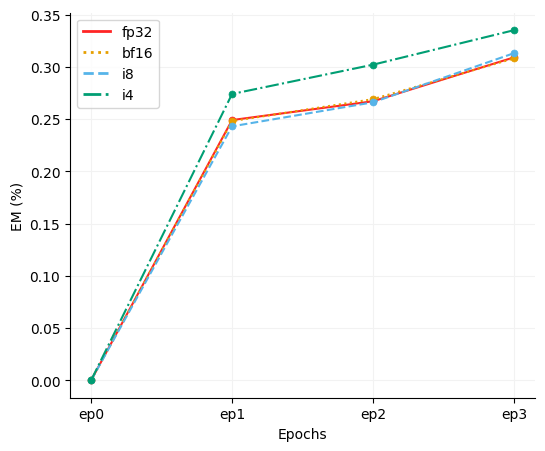

In [52]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], label=label, 
            color=colors[i], linestyle=linestyles[i], marker=markers[i], 
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Epochs')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_ep.pdf', format='pdf')

# Attack mem dedup

In [53]:
expath = '../attack_mem_dedup'
df_d1 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_1.parquet'))
df_d1_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_1.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d1', '15b_ep0_d1_em', '15b_ep0_d1_bleu',
       '15b_ep0_d1_meteor', '15b_ep0_d1_rougeL', '15b_ep3_d1', '15b_ep3_d1_em',
       '15b_ep3_d1_bleu', '15b_ep3_d1_meteor', '15b_ep3_d1_rougeL']]

merged_df_d1 = pd.merge(df_d1, df_d1_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


df_d2 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_2.parquet'))
df_d2_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_2.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d2', '15b_ep0_d2_em', '15b_ep0_d2_bleu',
       '15b_ep0_d2_meteor', '15b_ep0_d2_rougeL', '15b_ep3_d2', '15b_ep3_d2_em',
       '15b_ep3_d2_bleu', '15b_ep3_d2_meteor', '15b_ep3_d2_rougeL']]

merged_df_d2 = pd.merge(df_d2, df_d2_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_d3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_3.parquet'))
df_d3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d3', '15b_ep0_d3_em', '15b_ep0_d3_bleu',
       '15b_ep0_d3_meteor', '15b_ep0_d3_rougeL', '15b_ep3_d3', '15b_ep3_d3_em',
       '15b_ep3_d3_bleu', '15b_ep3_d3_meteor', '15b_ep3_d3_rougeL']]

merged_df_d3 = pd.merge(df_d3, df_d3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_dg3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_g3.parquet'))
df_dg3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_g3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_dg3', '15b_ep0_dg3_em', '15b_ep0_dg3_bleu',
       '15b_ep0_dg3_meteor', '15b_ep0_dg3_rougeL', '15b_ep3_dg3', '15b_ep3_dg3_em',
       '15b_ep3_dg3_bleu', '15b_ep3_dg3_meteor', '15b_ep3_dg3_rougeL']]

merged_df_dg3 = pd.merge(df_dg3, df_dg3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

dfs = [merged_df_d1, merged_df_d2, merged_df_d3, merged_df_dg3]
dedups = ['d1', 'd2', 'd3', 'dg3']
dedup_df_by_name = dict(zip(dedups, dfs))


## fp32

In [54]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_fp32_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'15b_{eps[1]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_fp32_absolute = dedup_fp32_absolute_ci[metrics].copy()
dedup_fp32_absolute_ci = round_metrics_with_ci_table(dedup_fp32_absolute_ci, decimals=3)
dedup_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.075,"[0.06, 0.093]",47.571,"[45.661, 49.445]",0.551,"[0.534, 0.568]",0.521,"[0.503, 0.539]"
d2,0.352,"[0.323, 0.382]",69.480,"[67.434, 71.524]",0.735,"[0.717, 0.753]",0.723,"[0.704, 0.741]"
d3,0.544,"[0.513, 0.575]",83.215,"[81.471, 84.905]",0.859,"[0.843, 0.874]",0.853,"[0.838, 0.869]"
dg3,0.609,"[0.578, 0.639]",77.448,"[75.172, 79.753]",0.801,"[0.78, 0.822]",0.797,"[0.775, 0.818]"


In [55]:
# With the baseline
dedup_fp32_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'15b_{eps[0]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_fp32_ep0 = dedup_fp32_ep0_ci[metrics].copy()
dedup_fp32_ep0_ci = round_metrics_with_ci_table(dedup_fp32_ep0_ci, decimals=3)

dedup_fp32_baseline = dedup_fp32_absolute.subtract(dedup_fp32_ep0)

dedup_fp32_baseline

,em,bleu,meteor,rougeL
d1,0.052,10.932447,0.090406,0.099935
d2,0.277,24.443996,0.215197,0.221894
d3,0.417,38.548428,0.324719,0.347771
dg3,0.310,19.865729,0.170740,0.171861


## bf16

In [56]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_bf16_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'bf16_{eps[1]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_bf16_absolute = dedup_bf16_absolute_ci[metrics].copy()
dedup_bf16_absolute_ci = round_metrics_with_ci_table(dedup_bf16_absolute_ci, decimals=3)
dedup_bf16_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.078,"[0.063, 0.096]",47.582,"[45.671, 49.449]",0.552,"[0.535, 0.568]",0.522,"[0.504, 0.54]"
d2,0.352,"[0.323, 0.382]",69.371,"[67.335, 71.417]",0.734,"[0.715, 0.752]",0.721,"[0.702, 0.74]"
d3,0.545,"[0.514, 0.576]",83.468,"[81.754, 85.153]",0.860,"[0.845, 0.875]",0.856,"[0.84, 0.871]"
dg3,0.610,"[0.579, 0.64]",77.305,"[75.016, 79.62]",0.801,"[0.779, 0.822]",0.796,"[0.773, 0.817]"


In [57]:
# With the baseline
dedup_bf16_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'bf16_{eps[0]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_bf16_ep0 = dedup_bf16_ep0_ci[metrics].copy()
dedup_bf16_ep0_ci = round_metrics_with_ci_table(dedup_bf16_ep0_ci, decimals=3)

dedup_bf16_baseline = dedup_bf16_absolute.subtract(dedup_bf16_ep0)

dedup_bf16_baseline

,em,bleu,meteor,rougeL
d1,0.055,10.655141,0.090650,0.097562
d2,0.277,24.699686,0.217790,0.223314
d3,0.418,38.660802,0.325104,0.348880
dg3,0.308,19.690140,0.171695,0.171181


## i8

In [58]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_i8_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'i8_{eps[1]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_i8_absolute = dedup_i8_absolute_ci[metrics].copy()
dedup_i8_absolute_ci = round_metrics_with_ci_table(dedup_i8_absolute_ci, decimals=3)
dedup_i8_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.077,"[0.062, 0.095]",47.783,"[45.889, 49.654]",0.554,"[0.537, 0.571]",0.522,"[0.505, 0.54]"
d2,0.350,"[0.321, 0.38]",69.166,"[67.132, 71.236]",0.732,"[0.714, 0.75]",0.719,"[0.7, 0.738]"
d3,0.541,"[0.51, 0.572]",83.070,"[81.351, 84.743]",0.858,"[0.842, 0.873]",0.853,"[0.837, 0.868]"
dg3,0.610,"[0.579, 0.64]",77.381,"[75.104, 79.7]",0.802,"[0.78, 0.823]",0.797,"[0.774, 0.818]"


In [59]:
# With the baseline
dedup_i8_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'i8_{eps[0]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_i8_ep0 = dedup_i8_ep0_ci[metrics].copy()
dedup_i8_ep0_ci = round_metrics_with_ci_table(dedup_i8_ep0_ci, decimals=3)

dedup_i8_baseline = dedup_i8_absolute.subtract(dedup_i8_ep0)

dedup_i8_baseline

,em,bleu,meteor,rougeL
d1,0.053,11.222983,0.096387,0.102009
d2,0.276,24.247739,0.215184,0.220578
d3,0.415,38.770142,0.325614,0.348131
dg3,0.313,20.259575,0.173198,0.176254


## i4

In [60]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_i4_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'i4_{eps[1]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_i4_absolute = dedup_i4_absolute_ci[metrics].copy()
dedup_i4_absolute_ci = round_metrics_with_ci_table(dedup_i4_absolute_ci, decimals=3)
dedup_i4_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.079,"[0.064, 0.097]",47.073,"[45.176, 48.925]",0.547,"[0.531, 0.564]",0.517,"[0.499, 0.535]"
d2,0.331,"[0.303, 0.361]",67.706,"[65.6, 69.796]",0.722,"[0.703, 0.741]",0.706,"[0.687, 0.726]"
d3,0.512,"[0.481, 0.543]",81.357,"[79.544, 83.122]",0.842,"[0.826, 0.857]",0.837,"[0.82, 0.853]"
dg3,0.583,"[0.552, 0.613]",76.788,"[74.499, 79.083]",0.795,"[0.773, 0.816]",0.790,"[0.768, 0.812]"


In [61]:
# With the baseline
dedup_i4_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][f'i4_{eps[0]}_{dedup_name}_{metric}'].dropna().to_numpy(),
)
dedup_i4_ep0 = dedup_i4_ep0_ci[metrics].copy()
dedup_i4_ep0_ci = round_metrics_with_ci_table(dedup_i4_ep0_ci, decimals=3)

dedup_i4_baseline = dedup_i4_absolute.subtract(dedup_i4_ep0)

dedup_i4_baseline

,em,bleu,meteor,rougeL
d1,0.056,10.827673,0.090239,0.097401
d2,0.258,22.782354,0.207810,0.205721
d3,0.393,37.390838,0.314389,0.338320
dg3,0.335,22.799994,0.189390,0.193727


## Visuals

In [62]:
df_dedup_mem_plot = pd.DataFrame({'fp32': dedup_fp32_baseline['em'],
                                  'bf16': dedup_bf16_baseline['em'],
                                  'i8': dedup_i8_baseline['em'],
                                  'i4': dedup_i4_baseline['em'],
                                  })
df_dedup_mem_plot

,fp32,bf16,i8,i4
d1,0.052,0.055,0.053,0.056
d2,0.277,0.277,0.276,0.258
d3,0.417,0.418,0.415,0.393
dg3,0.310,0.308,0.313,0.335


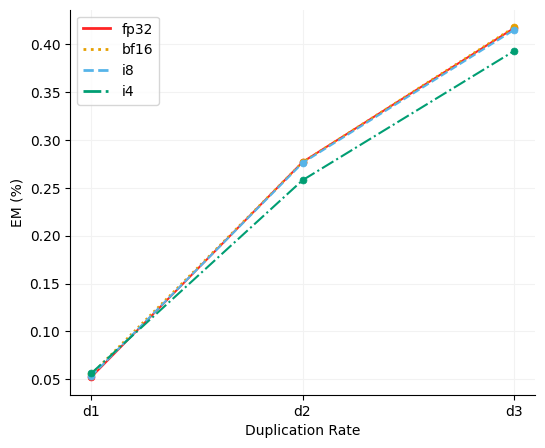

In [63]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_dedup_mem_plot.loc[["d1", "d2", "d3"]].index, df_dedup_mem_plot.loc[["d1", "d2", "d3"]][label],
            label=label,
            color=colors[i], linestyle=linestyles[i], marker=markers[i],
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Duplication Rate')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_dedup.pdf', format='pdf')

# Attack mem plen

In [64]:
expath = '../attack_mem_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_plen.parquet'))

df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_plen/attack_mem_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [65]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_fp32_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[1]}_{plen}_{metric}',
)
plen_fp32_absolute = plen_fp32_absolute_ci[metrics].copy()
plen_fp32_absolute_ci = round_metrics_with_ci_table(plen_fp32_absolute_ci, decimals=3)
plen_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.609,"[0.578, 0.639]",77.449,"[75.16, 79.781]",0.801,"[0.78, 0.822]",0.797,"[0.774, 0.818]"
p150,0.729,"[0.701, 0.756]",80.567,"[78.297, 82.72]",0.855,"[0.837, 0.873]",0.826,"[0.805, 0.846]"
p200,0.817,"[0.792, 0.84]",82.902,"[80.689, 85.051]",0.879,"[0.861, 0.896]",0.844,"[0.822, 0.864]"
p250,0.888,"[0.867, 0.906]",86.814,"[84.772, 88.836]",0.913,"[0.897, 0.928]",0.876,"[0.856, 0.895]"


In [66]:
# With the baseline
plen_fp32_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[0]}_{plen}_{metric}',
)
plen_fp32_ep0 = plen_fp32_ep0_ci[metrics].copy()
plen_fp32_ep0_ci = round_metrics_with_ci_table(plen_fp32_ep0_ci, decimals=3)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,0.310,19.874890,0.170796,0.171847
p150,0.372,21.684561,0.204705,0.191712
p200,0.441,23.207238,0.209227,0.198899
p250,0.474,24.393655,0.202508,0.200509


## bf16

In [67]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_bf16_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'bf16_{eps[1]}_{plen}_{metric}',
)
plen_bf16_absolute = plen_bf16_absolute_ci[metrics].copy()
plen_bf16_absolute_ci = round_metrics_with_ci_table(plen_bf16_absolute_ci, decimals=3)
plen_bf16_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.610,"[0.579, 0.64]",77.305,"[74.976, 79.623]",0.801,"[0.779, 0.821]",0.796,"[0.774, 0.817]"
p150,0.729,"[0.701, 0.756]",80.629,"[78.361, 82.778]",0.855,"[0.837, 0.873]",0.827,"[0.806, 0.847]"
p200,0.818,"[0.793, 0.841]",83.011,"[80.807, 85.164]",0.880,"[0.862, 0.897]",0.845,"[0.824, 0.865]"
p250,0.886,"[0.865, 0.904]",86.838,"[84.797, 88.861]",0.913,"[0.897, 0.929]",0.876,"[0.856, 0.895]"


In [68]:
# With the baseline
plen_bf16_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'bf16_{eps[0]}_{plen}_{metric}',
)
plen_bf16_ep0 = plen_bf16_ep0_ci[metrics].copy()
plen_bf16_ep0_ci = round_metrics_with_ci_table(plen_bf16_ep0_ci, decimals=3)
plen_bf16_baseline = plen_bf16_absolute.subtract(plen_bf16_ep0)
plen_bf16_baseline

,em,bleu,meteor,rougeL
p100,0.308,19.690140,0.171695,0.171181
p150,0.372,21.488027,0.204151,0.190602
p200,0.446,23.179070,0.214312,0.199980
p250,0.473,24.384591,0.201536,0.200508


§## i8

In [69]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_i8_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i8_{eps[1]}_{plen}_{metric}',
)
plen_i8_absolute = plen_i8_absolute_ci[metrics].copy()
plen_i8_absolute_ci = round_metrics_with_ci_table(plen_i8_absolute_ci, decimals=3)
plen_i8_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.610,"[0.579, 0.64]",77.381,"[75.079, 79.712]",0.802,"[0.78, 0.823]",0.797,"[0.774, 0.818]"
p150,0.730,"[0.702, 0.757]",80.759,"[78.53, 82.934]",0.855,"[0.837, 0.873]",0.828,"[0.807, 0.848]"
p200,0.815,"[0.79, 0.838]",83.000,"[80.813, 85.144]",0.880,"[0.862, 0.897]",0.844,"[0.823, 0.865]"
p250,0.887,"[0.866, 0.905]",86.989,"[84.958, 88.995]",0.915,"[0.899, 0.93]",0.877,"[0.857, 0.896]"


In [70]:
# With the baseline
plen_i8_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i8_{eps[0]}_{plen}_{metric}',
)
plen_i8_ep0 = plen_i8_ep0_ci[metrics].copy()
plen_i8_ep0_ci = round_metrics_with_ci_table(plen_i8_ep0_ci, decimals=3)
plen_i8_baseline = plen_i8_absolute.subtract(plen_i8_ep0)
plen_i8_baseline

,em,bleu,meteor,rougeL
p100,0.313,20.259575,0.173198,0.176254
p150,0.375,22.102467,0.207859,0.196809
p200,0.447,23.720824,0.216369,0.203748
p250,0.469,24.146236,0.193217,0.195693


## i4

In [71]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_i4_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i4_{eps[1]}_{plen}_{metric}',
)
plen_i4_absolute = plen_i4_absolute_ci[metrics].copy()
plen_i4_absolute_ci = round_metrics_with_ci_table(plen_i4_absolute_ci, decimals=3)
plen_i4_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.583,"[0.552, 0.613]",76.788,"[74.453, 79.078]",0.795,"[0.773, 0.816]",0.790,"[0.768, 0.812]"
p150,0.699,"[0.67, 0.727]",79.905,"[77.632, 82.092]",0.840,"[0.821, 0.859]",0.819,"[0.799, 0.84]"
p200,0.770,"[0.743, 0.795]",82.671,"[80.486, 84.806]",0.870,"[0.852, 0.888]",0.842,"[0.821, 0.862]"
p250,0.863,"[0.84, 0.883]",86.536,"[84.477, 88.572]",0.907,"[0.89, 0.923]",0.873,"[0.852, 0.892]"


In [72]:
# With the baseline
plen_i4_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i4_{eps[0]}_{plen}_{metric}',
)
plen_i4_ep0 = plen_i4_ep0_ci[metrics].copy()
plen_i4_ep0_ci = round_metrics_with_ci_table(plen_i4_ep0_ci, decimals=3)
plen_i4_baseline = plen_i4_absolute.subtract(plen_i4_ep0)
plen_i4_baseline

,em,bleu,meteor,rougeL
p100,0.369,26.046929,0.219355,0.219388
p150,0.451,28.210575,0.249759,0.240650
p200,0.491,30.112915,0.273353,0.253284
p250,0.573,31.325953,0.263943,0.253319


## Plots

In [73]:
df_plen_baseline = pd.DataFrame({'fp32': plen_fp32_baseline['em'],
                            'bf16': plen_bf16_baseline['em'],
                            'int8': plen_i8_baseline['em'],
                            'int4': plen_i4_baseline['em']
                            })
df_plen_baseline

,fp32,bf16,int8,int4
p100,0.310,0.308,0.313,0.369
p150,0.372,0.372,0.375,0.451
p200,0.441,0.446,0.447,0.491
p250,0.474,0.473,0.469,0.573


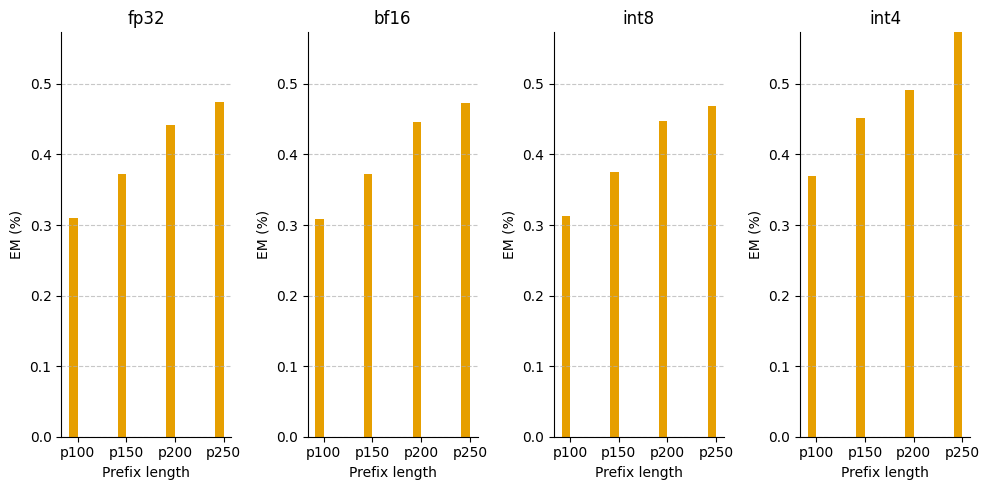

In [74]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_baseline.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'int8', 'int4']
max_value = max(df_plen_baseline.max().max(), df_plen_baseline.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    # positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_baseline[label], width, label='Base', color='#E69F00')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM (%)')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_baseline.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_mem_plen.pdf', format='pdf')

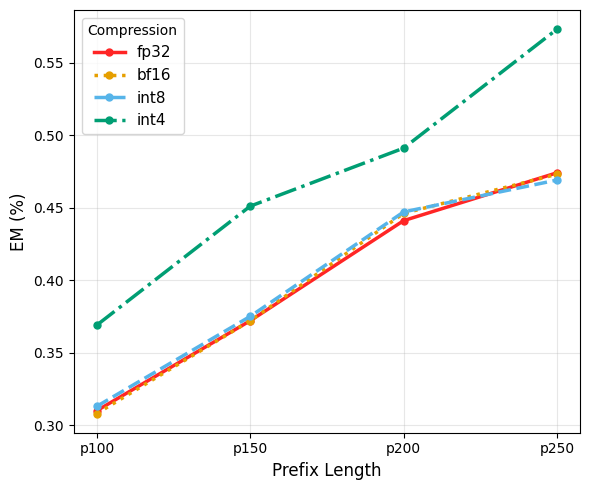

In [75]:
# Create a single figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

prefix_lengths = ['p100', 'p150', 'p200', 'p250']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

# Plot on the created axis (ax), not plt
for i, (compression, color, linestyle, marker) in enumerate(zip(df_plen_baseline.columns, colors, linestyles, markers)):
    ax.plot(range(len(prefix_lengths)), df_plen_baseline[compression],
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=compression, linestyle=linestyle)

# Use ax methods instead of plt methods
ax.set_xlabel('Prefix Length', fontsize=12)
ax.set_ylabel('EM (%)', fontsize=12)
# ax.set_title('Memorization Increases with Prefix Length and Compression', fontsize=14, pad=20)
ax.set_xticks(range(len(prefix_lengths)))
ax.set_xticklabels(prefix_lengths)
ax.legend(title='Compression', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('./quant_attack_mem_plen_dif1.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


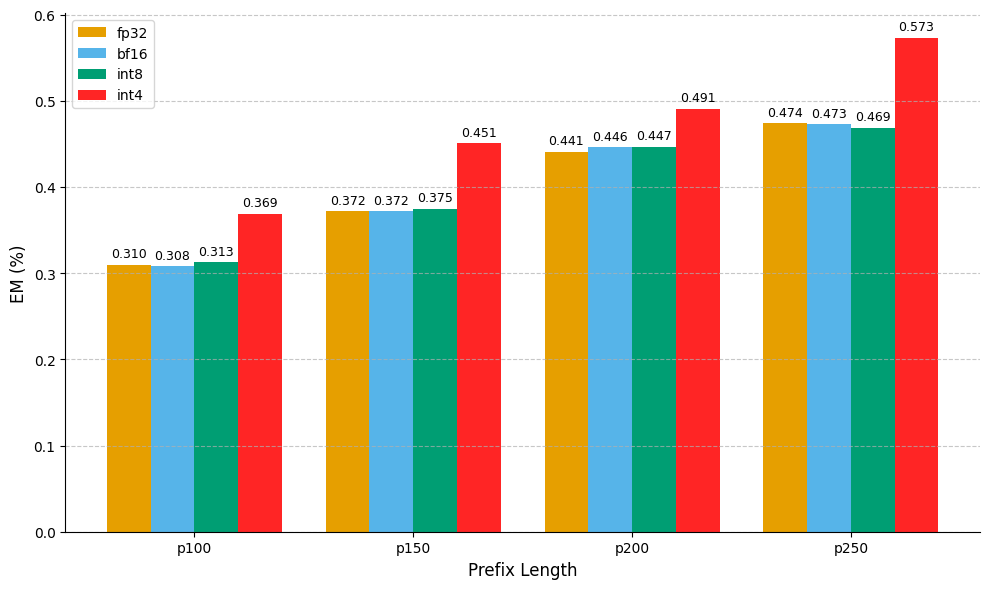

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the color palette for 4 different colors
colors = ['#E69F00', '#56B4E9', '#009E73', '#FF2525']

# Create the barplot
fig, ax = plt.subplots(figsize=(10, 6))

# Use prefix length data instead of categories
prefix_data = df_plen_baseline
x_plen = np.arange(len(prefix_data.index))  # p100, p150, p200, p250
width = 0.2

# Create bars for each precision setting
bars1 = ax.bar(x_plen - 1.5*width, prefix_data['fp32'], width, label='fp32', color=colors[0])
bars2 = ax.bar(x_plen - 0.5*width, prefix_data['bf16'], width, label='bf16', color=colors[1])
bars3 = ax.bar(x_plen + 0.5*width, prefix_data['int8'], width, label='int8', color=colors[2])
bars4 = ax.bar(x_plen + 1.5*width, prefix_data['int4'], width, label='int4', color=colors[3])

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)
add_value_labels(bars4)

# Customize the plot
ax.set_xlabel('Prefix Length', fontsize=12)
ax.set_ylabel('EM (%)', fontsize=12)
# ax.set_title('Memorization by Prefix Length and Precision Setting')
ax.set_xticks(x_plen)
ax.set_xticklabels(prefix_data.index)  # p100, p150, p200, p250
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Adjust layout and show
plt.tight_layout()
plt.savefig('./quant_plen_bar.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

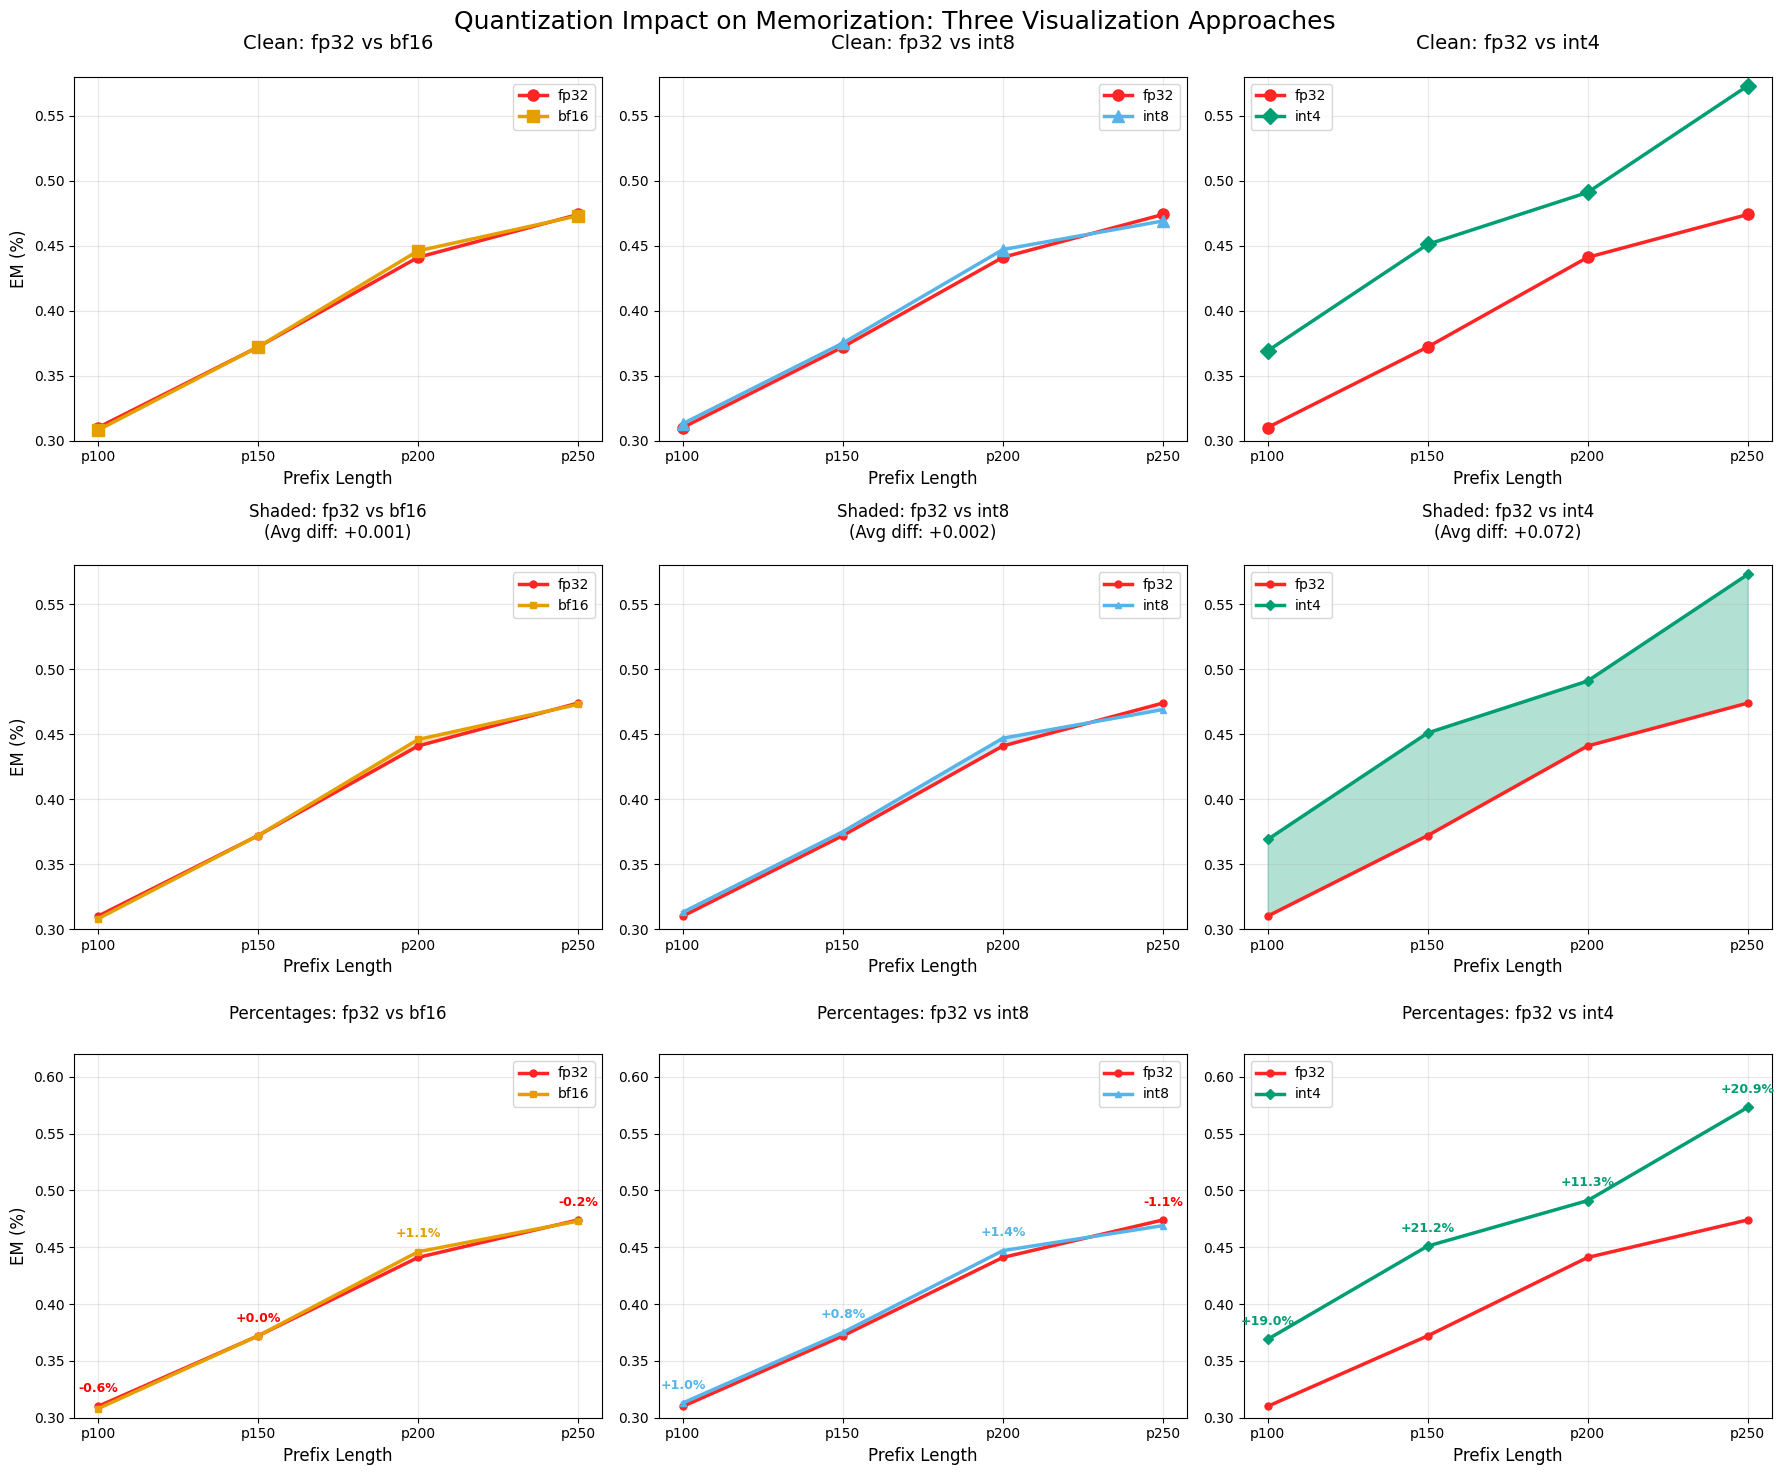

In [77]:
prefix_lengths = ['p100', 'p150', 'p200', 'p250']

# Create a large figure with 3 rows and 3 columns (9 subplots total)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Colors and markers
fp32_color = '#FF2525'
comparison_colors = ['#E69F00', '#56B4E9', '#009E73']
fp32_marker = 'o'
comparison_markers = ['s', '^', 'D']

# Comparison models
comparison_models = ['bf16', 'int8', 'int4']

# VERSION 1: Clean comparison (Row 0)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[0, i]

    # Plot fp32 baseline
    ax.plot(range(len(prefix_lengths)), df_plen_baseline['fp32'],
            marker=fp32_marker, linewidth=2.5, markersize=8,
            color=fp32_color, label='fp32', linestyle='-')

    # Plot comparison model
    ax.plot(range(len(prefix_lengths)), df_plen_baseline[model],
            marker=marker, linewidth=2.5, markersize=8,
            color=color, label=model, linestyle='-')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:  # Only leftmost plot gets y-label
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'Clean: fp32 vs {model}', fontsize=14, pad=20)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.58)

# VERSION 2: With difference shading (Row 1)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[1, i]
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-', zorder=3)

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-', zorder=3)

    # Fill area between lines to show difference
    ax.fill_between(x_vals, fp32_vals, model_vals,
                    alpha=0.3, color=color if model_vals.mean() > fp32_vals.mean() else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:  # Only leftmost plot gets y-label
        ax.set_ylabel('EM (%)', fontsize=12)

    # Calculate average difference for title
    avg_diff = (model_vals - fp32_vals).mean()
    ax.set_title(f'Shaded: fp32 vs {model}\n(Avg diff: {avg_diff:+.3f})', fontsize=12, pad=20)

    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.58)

# VERSION 3: With improvement percentages (Row 2)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[2, i]
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-')

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-')

    # Add percentage difference annotations
    for j, (x, fp32_val, model_val) in enumerate(zip(x_vals, fp32_vals, model_vals)):
        pct_diff = ((model_val - fp32_val) / fp32_val) * 100
        # Position annotation above the higher line
        y_pos = max(fp32_val, model_val) + 0.01
        ax.annotate(f'{pct_diff:+.1f}%',
                   xy=(x, y_pos), ha='center', va='bottom',
                   fontsize=9, fontweight='bold',
                   color=color if pct_diff > 0 else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'Percentages: fp32 vs {model}', fontsize=12, pad=25)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.62)

# Add overall title
fig.suptitle('Quantization Impact on Memorization: Three Visualization Approaches',
             fontsize=18, y=0.98)

plt.tight_layout()
fig.savefig('./quant_attack_mem_plen_combined.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

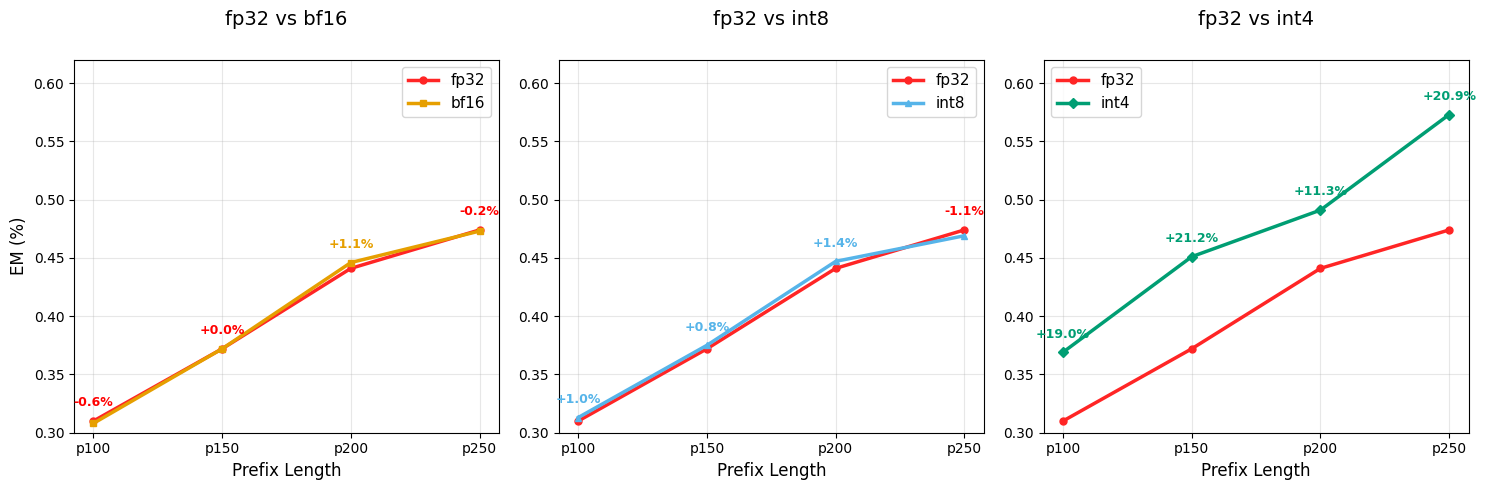

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, model, color, marker) in enumerate(zip(axes, comparison_models, comparison_colors, comparison_markers)):
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-')

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-')

    # Add percentage difference annotations
    for j, (x, fp32_val, model_val) in enumerate(zip(x_vals, fp32_vals, model_vals)):
        pct_diff = ((model_val - fp32_val) / fp32_val) * 100
        # Position annotation above the higher line
        y_pos = max(fp32_val, model_val) + 0.01
        ax.annotate(f'{pct_diff:+.1f}%',
                   xy=(x, y_pos), ha='center', va='bottom',
                   fontsize=9, fontweight='bold',
                   color=color if pct_diff > 0 else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'fp32 vs {model}', fontsize=14, pad=25)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Set same y-limits with extra space for annotations
    ax.set_ylim(0.3, 0.62)

plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_mem_plen_dif3.pdf', format='pdf')
